# GradientBoosting

### 수업자료 06_machin_learning\10_앙상블_부스팅.ipynb에 근거한 GradioentBoosting 모델링 


In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier


In [85]:
df = pd.read_csv("../data/synthetic_customer_churn_100k.csv", skipinitialspace=True)
df.shape

(100000, 9)

In [86]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
0,1,56,Female,68,147.58,Two year,Bank transfer,10052.03,No
1,2,69,Male,32,22.54,Month-to-month,Mailed check,686.78,No
2,3,46,Female,10,52.47,One year,Electronic check,537.88,No
3,4,32,Male,22,109.67,Month-to-month,Mailed check,2390.04,Yes
4,5,60,Female,54,130.98,Month-to-month,Credit card,7081.28,No


In [87]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   CustomerID      100000 non-null  int64  
 1   Age             100000 non-null  int64  
 2   Gender          100000 non-null  str    
 3   Tenure          100000 non-null  int64  
 4   MonthlyCharges  100000 non-null  float64
 5   Contract        100000 non-null  str    
 6   PaymentMethod   100000 non-null  str    
 7   TotalCharges    100000 non-null  float64
 8   Churn           100000 non-null  str    
dtypes: float64(2), int64(3), str(4)
memory usage: 6.9 MB


In [88]:
df.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,49.027240,36.527090,79.974933,2926.140256
std,28867.657797,18.177862,20.789552,40.491961,2388.163672
min,1.000000,18.000000,1.000000,10.000000,-118.430000
25%,25000.750000,33.000000,18.000000,44.720000,963.667500
50%,50000.500000,49.000000,37.000000,80.000000,2268.060000
75%,75000.250000,65.000000,54.000000,115.050000,4394.327500
max,100000.000000,80.000000,72.000000,150.000000,10831.460000


(array([5956., 9901., 9438., 8043., 7208., 6306., 5714., 5032., 4685.,
        4255., 3788., 3471., 3188., 2928., 2704., 2514., 2163., 2042.,
        1835., 1642., 1425., 1260., 1116.,  876.,  764.,  665.,  470.,
         335.,  195.,   81.]),
 array([ -118.43      ,   246.56633333,   611.56266667,   976.559     ,
         1341.55533333,  1706.55166667,  2071.548     ,  2436.54433333,
         2801.54066667,  3166.537     ,  3531.53333333,  3896.52966667,
         4261.526     ,  4626.52233333,  4991.51866667,  5356.515     ,
         5721.51133333,  6086.50766667,  6451.504     ,  6816.50033333,
         7181.49666667,  7546.493     ,  7911.48933333,  8276.48566667,
         8641.482     ,  9006.47833333,  9371.47466667,  9736.471     ,
        10101.46733333, 10466.46366667, 10831.46      ]),
 <BarContainer object of 30 artists>)

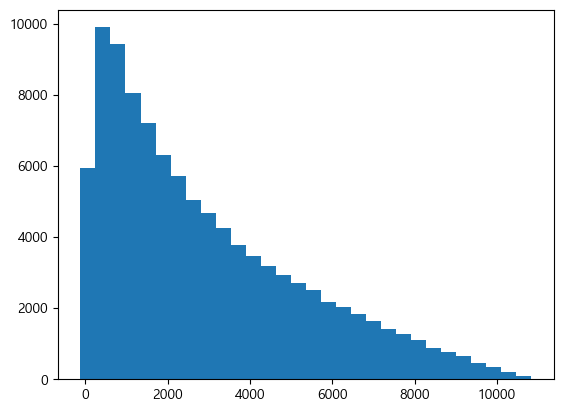

In [89]:
plt.hist(df["TotalCharges"], bins=30)

<BarContainer object of 2 artists>

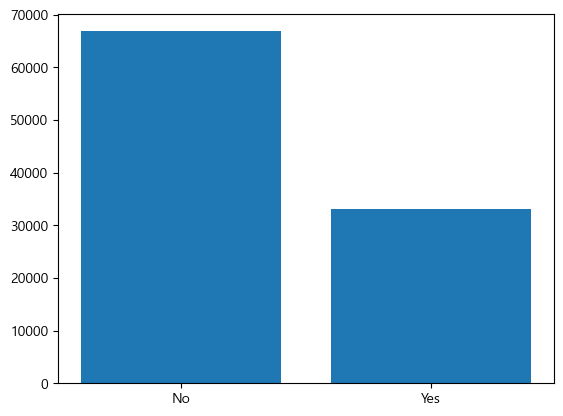

In [90]:
counts = df["Churn"].value_counts()
plt.bar(counts.index, counts.values)

In [91]:
df.isnull().sum()

CustomerID        0
Age               0
Gender            0
Tenure            0
MonthlyCharges    0
Contract          0
PaymentMethod     0
TotalCharges      0
Churn             0
dtype: int64

In [92]:
df["testfier"] = df["Tenure"]*df["MonthlyCharges"]-df["TotalCharges"]
df = df.sort_values('testfier', ascending=False)
df
(df["Tenure"] != 0).sum()

np.int64(100000)

In [93]:
df

,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn,testfier
45954,45955,51,Male,50,77.32,Two year,Mailed check,3648.06,No,217.94
45646,45647,64,Male,61,84.37,Month-to-month,Credit card,4944.05,Yes,202.52
14693,14694,36,Female,2,72.63,Month-to-month,Credit card,-49.45,Yes,194.71
30071,30072,59,Female,45,90.66,Two year,Bank transfer,3886.36,No,193.34
65366,65367,75,Male,19,99.10,One year,Mailed check,1689.99,No,192.91
...,...,...,...,...,...,...,...,...,...,...
41643,41644,77,Male,6,132.52,One year,Bank transfer,1004.10,Yes,-208.98
8934,8935,78,Male,9,78.37,Month-to-month,Electronic check,917.70,No,-212.37
16445,16446,61,Female,58,109.83,Month-to-month,Mailed check,6587.27,Yes,-217.13
43587,43588,32,Male,3,44.03,Month-to-month,Mailed check,354.74,Yes,-222.65


In [94]:
df["testfier"].describe()

count    100000.000000
mean          0.142277
std          50.042269
min        -224.970000
25%         -33.460000
50%          -0.120000
75%          34.030000
max         217.940000
Name: testfier, dtype: float64

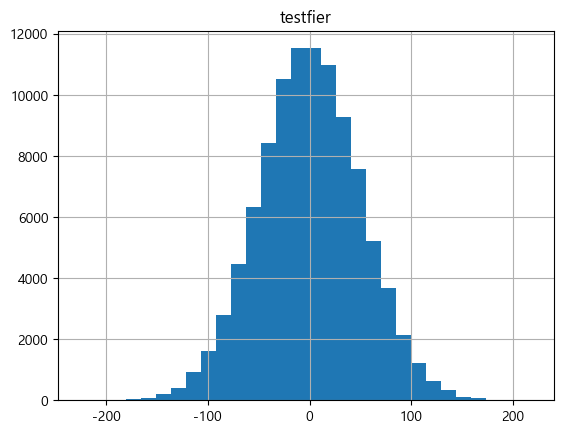

In [95]:
df["testfier"].hist(bins=30)
plt.title("testfier")
plt.show()

### EDA 분석 권고에 따라 TotalCharges 음수값을 0으로 대체
### categorical_columns은 label encoding을 하고
### numeric_columns은 scalinf 하지 않음

In [96]:
# 음수 개수 확인
neg_count = (df['TotalCharges'] < 0).sum()
print(f"음수 개수: {neg_count}개")

# 0으로 교체
df['TotalCharges'] = df['TotalCharges'].apply(lambda x: 0 if x < 0 else x)
neg_count = (df['TotalCharges'] < 0).sum()
print(f"음수 개수: {neg_count}개")

음수 개수: 265개
음수 개수: 0개


In [97]:
# X, y 분리

from sklearn.preprocessing import LabelEncoder
print("분리전:", df.shape)
print(df["Churn"].value_counts())
print("-----------------------------")
le = LabelEncoder()
y = le.fit_transform(df["Churn"])
X = df.drop(columns=["CustomerID", "Churn"]) # CustomerID는 의미 없어서 지움
print("분리후:", X.shape, y.shape)
print(pd.Series(y).value_counts())

분리전: (100000, 10)
Churn
No     66856
Yes    33144
Name: count, dtype: int64
-----------------------------
분리후: (100000, 8) (100000,)
0    66856
1    33144
Name: count, dtype: int64


In [98]:
# train/val/test set 분리

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=0, stratify=y_train) # train 60%, val 20%, test 20% 비율로 생성
    

In [99]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

categorical_columns = ['Gender','Contract','PaymentMethod'] 
numeric_columns = ['Tenure','MonthlyCharges', 'TotalCharges','Age'] 

# 범주형 컬럼 전처리 파이프라인
categorical_preprocessing = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")), 
    ("label", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

# 수치형 컬럼 전처리 파이프라인
numeric_preprocessing = Pipeline([
    ("imputer", SimpleImputer(strategy="median")), 
    # ("scaler", StandardScaler())
])

# ColumnTransformer로 컬럼별로 전처리 파이프라인 정의.
preprocessing = ColumnTransformer([
    ("category", categorical_preprocessing, categorical_columns),
    ("number", numeric_preprocessing, numeric_columns)
])
# preprocessing
# 전처리기와 모델을 묶는 파이프라인

pipeline = Pipeline([
    ("preprocessor", preprocessing),  # 1
    ("model", DecisionTreeClassifier(random_state=0))  # 2
])


In [100]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('category', ...), ('number', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfo

In [101]:
print("Depth 조회:", pipeline.named_steps["model"].get_depth())
print("Leaf nodes의 개수:", pipeline.named_steps["model"].get_n_leaves())

Depth 조회: 66
Leaf nodes의 개수: 12539


In [102]:
pipeline.named_steps["model"].feature_importances_

array([0.02531021, 0.10632813, 0.0482954 , 0.17777055, 0.30195571,
       0.20115964, 0.13918036])

In [103]:
# 수업중 사용한 metrics.py 파일 

from metrics import print_binary_classification_metrics
print_binary_classification_metrics(
    y_train,
    pipeline.predict(X_train), 
    pipeline.predict_proba(X_train)[:, 1],
    "Train set 평가결과"
)

Train set 평가결과
정확도: 1.0
재현율: 1.0
정밀도: 1.0
F1 점수: 1.0
Average Precision: 1.0
ROC-AUC Score: 1.0


In [104]:
from metrics import print_binary_classification_metrics
print_binary_classification_metrics(
    y_val,
    pipeline.predict(X_val), 
    pipeline.predict_proba(X_val)[:, 1],
    "Validation set 평가결과"
)

Validation set 평가결과
정확도: 0.6811
재현율: 0.5171217378186755
정밀도: 0.519000757002271
F1 점수: 0.5180595435998187
Average Precision: 0.42843657339022256
ROC-AUC Score: 0.6397589842335468


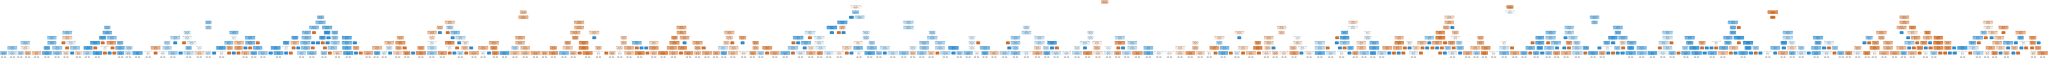

In [105]:
from sklearn.tree import export_graphviz
from graphviz import Source

feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

graph = Source(
    export_graphviz(
        pipeline.named_steps["model"], 
        feature_names=feature_names,
        class_names=['Yes', 'No'], 
        filled=True,
        rounded=True,
        max_depth=10,  # 트리의 깊이를 제한하여 시각화가 너무 복잡해지는 것을 방지
    )
)
graph

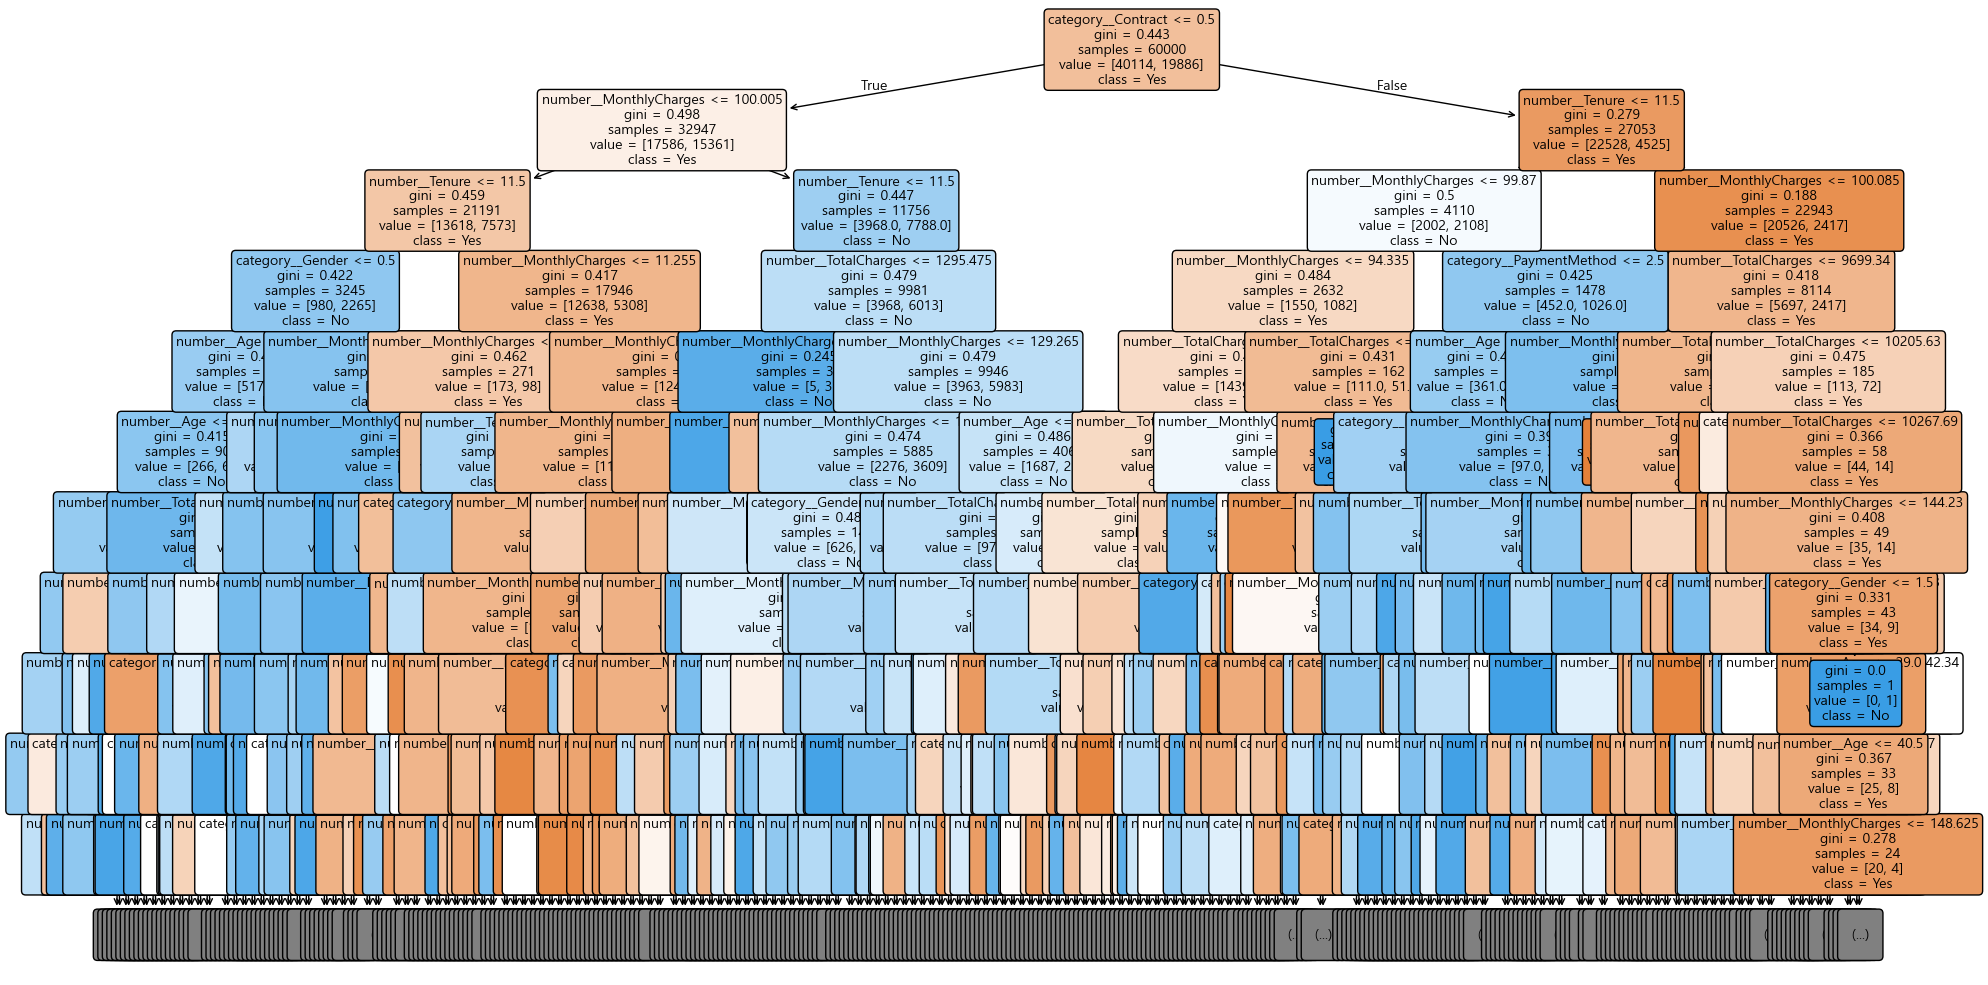

In [106]:
# Graphviz 설치가 어려운 경우, sklearn의 plot_tree 함수를 사용하여 트리를 시각화할 수 있습니다.

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
tree_model = pipeline.named_steps["model"]

plt.figure(figsize=(20, 10))
plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=['Yes', 'No'],
    filled=True,
    rounded=True,
    max_depth=10,
    fontsize=10
)
plt.tight_layout()
plt.show()

In [107]:
# fit() 뒤에 feature 중요도 조회
fi = pipeline.named_steps["model"].feature_importances_
fi

array([0.02531021, 0.10632813, 0.0482954 , 0.17777055, 0.30195571,
       0.20115964, 0.13918036])

In [108]:
fi.sum()

np.float64(0.9999999999999999)

In [109]:
import pandas as pd
fi_s = pd.Series(fi, index=feature_names).sort_values(ascending=False)
fi_s

number__MonthlyCharges     0.301956
number__TotalCharges       0.201160
number__Tenure             0.177771
number__Age                0.139180
category__Contract         0.106328
category__PaymentMethod    0.048295
category__Gender           0.025310
dtype: float64

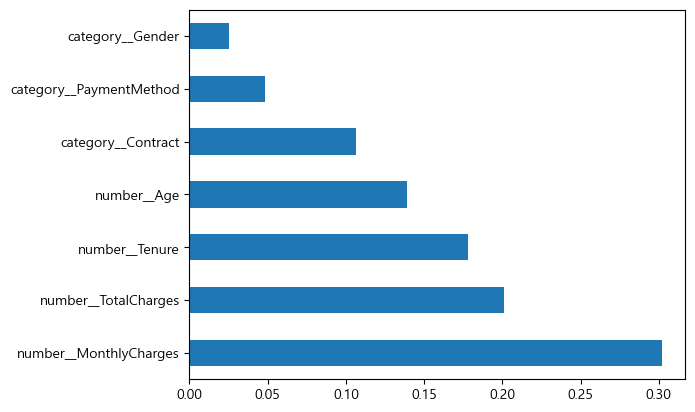

In [110]:
fi_s.plot(kind='barh');

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

import time

categorical_columns = ['Gender','Contract','PaymentMethod'] 
numeric_columns = ['Tenure','MonthlyCharges', 'TotalCharges','Age'] 

# 범주형 컬럼 전처리 파이프라인
categorical_preprocessing = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")), 
    ("label", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

# 수치형 컬럼 전처리 파이프라인
numeric_preprocessing = Pipeline([
    ("imputer", SimpleImputer(strategy="median")), 
    # ("scaler", StandardScaler())
])

# ColumnTransformer로 컬럼별로 전처리 파이프라인 정의.
preprocessing = ColumnTransformer([
    ("category", categorical_preprocessing, categorical_columns),
    ("number", numeric_preprocessing, numeric_columns)
])

# 전처리기와 모델을 묶는 파이프라인
pipeline = Pipeline([
    ("preprocessor", preprocessing),  # 1
    ("model", GradientBoostingClassifier(random_state=0))  # 2
])

# gridsearch

# 파라미터 그리드 (파이프라인에서는 "model__" 접두사 필요)
param_grid = {
    "model__n_estimators": [10_000],
    "model__learning_rate": [0.0001, 0.01],
    "model__max_depth": [1, 2, 3],
    # "preprocessor__number__imputer__strategy": ["mean", "median"]
    # Pipeline의 processor 안의 number 안의 imputer의 하이퍼파라미터 strategy
}

# 그리드서치 정의
gs = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='accuracy',
    n_jobs=-1,
    cv=4
)

s = time.time()
gs.fit(X_train, y_train)
e = time.time()
print(f"학습 시간: {e - s:.2f}초")


In [ ]:
gs.cv_results_

{'mean_fit_time': array([474.93679678, 476.34736192, 471.19274867, 472.82827008]),
 'std_fit_time': array([2.17279994, 1.0493809 , 1.16057312, 0.26687825]),
 'mean_score_time': array([1.58006406, 1.35010719, 2.15906608, 1.972471  ]),
 'std_score_time': array([0.32904506, 0.04858088, 0.09160364, 0.04182053]),
 'param_model__learning_rate': masked_array(data=[0.0001, 0.0001, 0.01, 0.01],
              mask=[False, False, False, False],
        fill_value=1e+20),
 'param_model__n_estimators': masked_array(data=[10000, 10000, 10000, 10000],
              mask=[False, False, False, False],
        fill_value=999999),
 'param_preprocessor__number__imputer__strategy': masked_array(data=['most_frequent', 'median', 'most_frequent', 'median'],
              mask=[False, False, False, False],
        fill_value=np.str_('?'),
             dtype=object),
 'params': [{'model__learning_rate': 0.0001,
   'model__n_estimators': 10000,
   'preprocessor__number__imputer__strategy': 'most_frequent'},
  {'

In [ ]:
pd.DataFrame(gs.cv_results_).sort_values("rank_test_score")

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__learning_rate,param_model__n_estimators,param_preprocessor__number__imputer__strategy,params,split0_test_score,split1_test_score,mean_test_score,std_test_score,rank_test_score
3,472.828270,0.266878,1.972471,0.041821,0.0100,10000,median,"{'model__learning_rate': 0.01, 'model__n_estim...",0.756300,0.753667,0.754983,0.001317,1
2,471.192749,1.160573,2.159066,0.091604,0.0100,10000,most_frequent,"{'model__learning_rate': 0.01, 'model__n_estim...",0.756300,0.753667,0.754983,0.001317,1
1,476.347362,1.049381,1.350107,0.048581,0.0001,10000,median,"{'model__learning_rate': 0.0001, 'model__n_est...",0.732067,0.760900,0.746483,0.014417,3
0,474.936797,2.172800,1.580064,0.329045,0.0001,10000,most_frequent,"{'model__learning_rate': 0.0001, 'model__n_est...",0.732067,0.760900,0.746483,0.014417,3


In [ ]:
# 1. 학습
gs.fit(X_train, y_train)

# 2. 전체 결과
print(gs.cv_results_)

# 3. 최적 파라미터 확인
print(gs.best_params_)
print(gs.best_score_)

# 4. 예측 
# 방법 1
# pred_train = gs.predict(X_train)
# pred_val = gs.predict(X_val)
# pred_val_proba = gs.predict(X_test)
# pred_test       = best_model.predict(X_test)
# pred_test_proba = best_model.predict_proba(X_test)


# 방법 2: best_estimator_ 추출 후 예측
best_model = gs.best_estimator_
pred_train       = best_model.predict(X_train)
pred_train_proba = best_model.predict(X_train)
pred_val        = best_model.predict(X_val)
pred_val_proba  = best_model.predict_proba(X_val)
pred_test       = best_model.predict(X_test)
pred_test_proba = best_model.predict_proba(X_test)


# 5. 평가
from metrics import print_binary_classification_metrics
print_binary_classification_metrics(
    y_train, pred_train, pred_train_proba[:, 1], "Train set"
)

from metrics import print_binary_classification_metrics
print_binary_classification_metrics(
    y_val, pred_val, pred_val_proba[:, 1], "Val set"
)

from metrics import print_binary_classification_metrics
print_binary_classification_metrics(
    y_test, pred_test, pred_test_proba[:, 1], "Test set"
)

# # 6. 저장(py 파일 기준)
# import joblib
# import os

# base_dir = os.path.dirname(os.path.abspath(__file__))
# save_dir = os.path.join(base_dir, "saved_model")
# os.makedirs(save_dir, exist_ok=True)

# joblib.dump(best_model, os.path.join(save_dir, "best_model.pkl"))
# print("저장 완료")

# #7. 불러오기
# best_model = joblib.load(os.path.join(save_dir, "best_model.pkl"))
# y_pred = best_model.predict(X_test)

# 6. 저장(ipynb기준)
import joblib
import os

save_dir = os.path.join(os.getcwd(), "saved_model")
os.makedirs(save_dir, exist_ok=True)
joblib.dump(best_model, os.path.join(save_dir, "best_model.pkl"))
joblib.dump(X_train, os.path.join(save_dir, "X_train.pkl"))
joblib.dump(X_val,   os.path.join(save_dir, "X_val.pkl"))
joblib.dump(X_test,  os.path.join(save_dir, "X_test.pkl"))
joblib.dump(y_train, os.path.join(save_dir, "y_train.pkl"))
joblib.dump(y_val,   os.path.join(save_dir, "y_val.pkl"))
joblib.dump(y_test,  os.path.join(save_dir, "y_test.pkl"))
print(f"저장 완료: {save_dir}")

# 7. 불러오기
import joblib
import os
save_dir = os.path.join(os.getcwd(), "saved_model")
best_model = joblib.load(os.path.join(save_dir, "best_model.pkl"))
X_train = joblib.load(os.path.join(save_dir, "X_train.pkl"))
X_val   = joblib.load(os.path.join(save_dir, "X_val.pkl"))
X_test  = joblib.load(os.path.join(save_dir, "X_test.pkl"))
y_train = joblib.load(os.path.join(save_dir, "y_train.pkl"))
y_val   = joblib.load(os.path.join(save_dir, "y_val.pkl"))
y_test  = joblib.load(os.path.join(save_dir, "y_test.pkl"))
print("불러오기 완료")

# .gitignore에 *.pkl 등록

Fitting 2 folds for each of 4 candidates, totalling 8 fits
{'mean_fit_time': array([544.00797927, 542.11352646, 533.41451132, 533.59746528]), 'std_fit_time': array([0.25980294, 0.20447814, 0.12148273, 1.13022184]), 'mean_score_time': array([1.24106812, 2.05944312, 5.20183611, 5.18586171]), 'std_score_time': array([0.01193738, 0.15347278, 0.00050092, 0.01769125]), 'param_model__learning_rate': masked_array(data=[0.0001, 0.0001, 0.01, 0.01],
             mask=[False, False, False, False],
       fill_value=1e+20), 'param_model__n_estimators': masked_array(data=[10000, 10000, 10000, 10000],
             mask=[False, False, False, False],
       fill_value=999999), 'param_preprocessor__number__imputer__strategy': masked_array(data=['most_frequent', 'median', 'most_frequent', 'median'],
             mask=[False, False, False, False],
       fill_value=np.str_('?'),
            dtype=object), 'params': [{'model__learning_rate': 0.0001, 'model__n_estimators': 10000, 'preprocessor__number__imp

In [ ]:
best_model = gs.best_estimator_

feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
fi = pd.Series(
    best_model.named_steps["model"].feature_importances_,
    index=feature_names
).sort_values(ascending=False)
fi

number__MonthlyCharges     0.321849
number__Tenure             0.299451
category__Contract         0.291266
number__TotalCharges       0.066421
number__Age                0.014844
category__PaymentMethod    0.004179
category__Gender           0.001990
dtype: float64

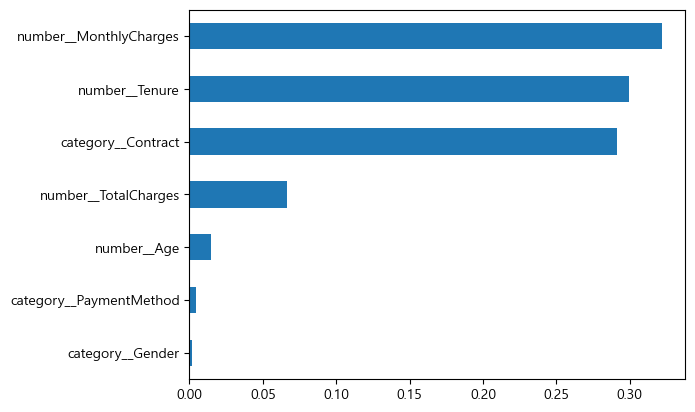

In [ ]:
fi.sort_values().plot(kind="barh");

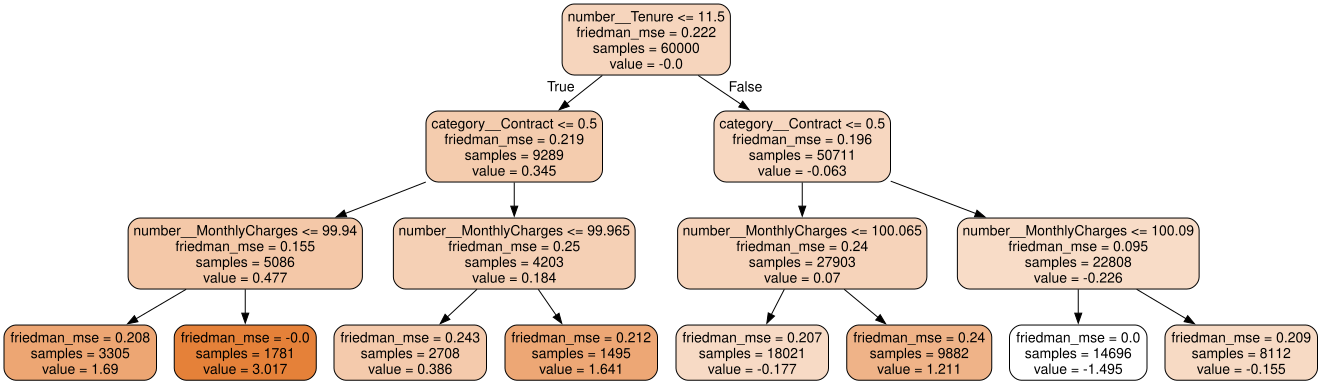

In [ ]:
from sklearn.tree import export_graphviz
from graphviz import Source

# Pipeline에서 실제 모델 추출해야 하는데 GradientBoostingClassifier는 단일 트리가 아니라  
# GradientBoosting 내부의 각각의 트리를 추출해야 함     
tree_model = best_model.named_steps["model"].estimators_[0][0]

graph = Source(
    export_graphviz(
        tree_model, 
        feature_names=feature_names,
        class_names = ["Yes", "No"],
        filled=True,
        rounded=True
    )
)
graph

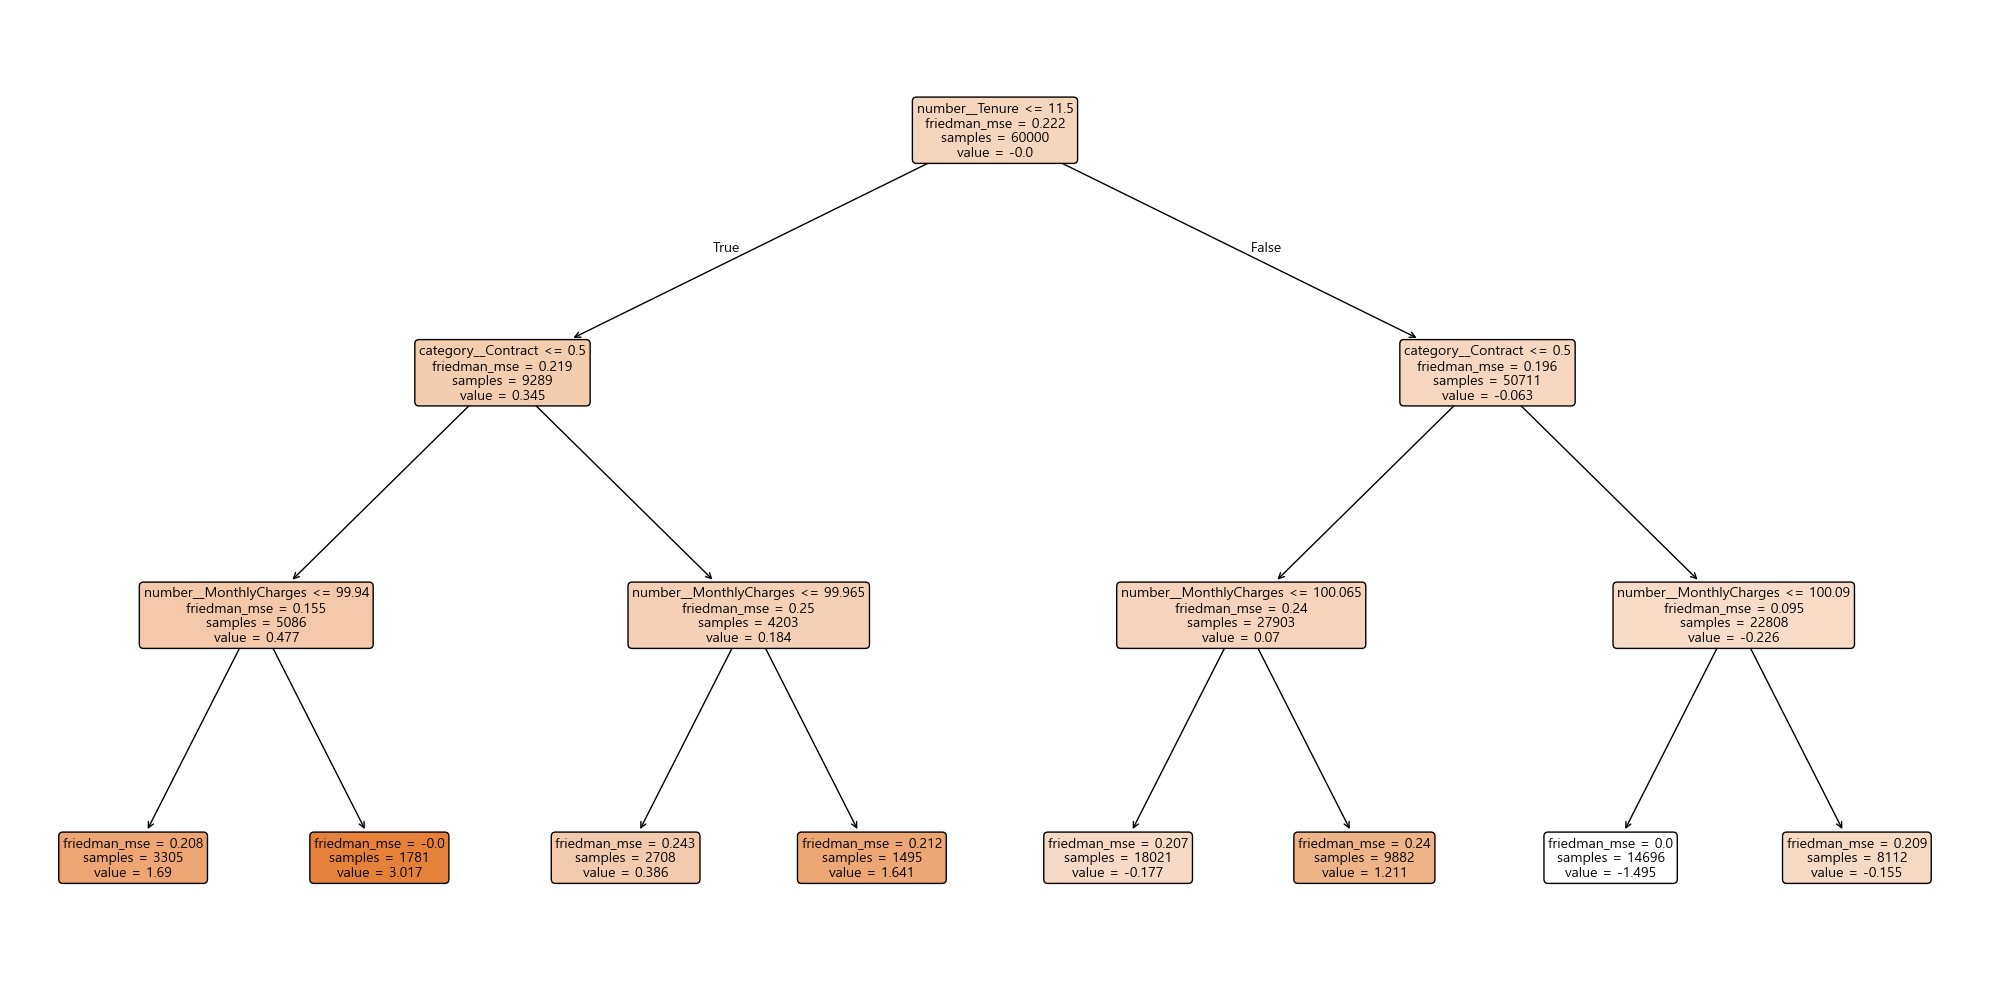

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(
    best_model.named_steps["model"].estimators_[0][0],
    feature_names=feature_names,
    class_names=["Yes", "No"],
    filled=True,
    rounded=True,
    max_depth=10,
    fontsize=10
)
plt.tight_layout()
plt.show()

In [ ]:
# "model__" 접두사 제거
best_params = {k.replace("model__", ""): v for k, v in gs.best_params_.items() if k.startswith("model__")}
print("정제된 파라미터:", best_params)



정제된 파라미터: {'learning_rate': 0.01, 'n_estimators': 10000}
